In [1]:
from InSitu14CO import Propagator
import numpy as np
import matplotlib.pyplot as plt
import crflux.models as pm
import matplotlib.ticker as ticker
import matplotlib as mpl
import Functions_14CO as F

from tqdm import tqdm

import pandas as pd

from scipy import stats

from scipy.ndimage import gaussian_filter

import pyunfold as pu

from scipy.io import loadmat

In [2]:
def T(A):
    return np.swapaxes(A, -2, -1)

In [3]:
site = 'DomeC'
Prop = Propagator()
density_model = ('MSIS00', ('SouthPole', 'January'))

In [4]:
df_Pfast = pd.read_csv('Production Rates/P_fast_SouthPole_3120m.csv')
df_Pneg = pd.read_csv('Production Rates/P_neg_SouthPole_3120m.csv')
P_14C = np.swapaxes([df_Pfast.T, df_Pneg.T], 0, 1)
model_names = list(df_Pfast.columns)

# The only production model being used is Heisinger
i = model_names.index('Heisinger')
prod_cut = np.arange(len(P_14C))[i:i+1]

Prop.Phi['prod']=P_14C[prod_cut]
C_flow_response = F.flow_14C_response(Prop)
C_response = C_flow_response @ Prop.S_mat[Prop.i_start:]

In [5]:
# sets the conditions for the study at Taylor Glacier by Dyonisius et al. (https://tc.copernicus.org/articles/17/843/2023/)
Prop_TG = Propagator(pressure=9.248658001389917e+04, # (Pa) pressure used in Taylor Glacier analysis "from LSD ERA reanalysis"
              elev=526, # (m) elevation listed in Figure 1 caption of Taylor Glacier study (need to confirm)
              rho_ice=0.92) # (g/cm^3) density used in Taylor Glacier analysis
h_bins_TG = np.arange(0, 1001, 1)
Prop_TG.set_mass_depth(z_bins=h_bins_TG/Prop_TG.rho_ice, h_bins=h_bins_TG, z_min=0., z_deep=h_bins_TG[-1]/Prop_TG.rho_ice)
# sample mid depths = [6.85, 10., 15, 19.5, 40.5, 51, 61.5, 72.]
density_model = ('MSIS00', ('SouthPole', 'January'))

In [6]:
df_Pfast_TG = pd.read_csv('Production Rates/P_fast_TaylorGlacier_526m.csv')
df_Pneg_TG = pd.read_csv('Production Rates/P_neg_TaylorGlacier_526m.csv')
P_14C_TG = np.swapaxes([df_Pfast_TG.T, df_Pneg_TG.T], 0, 1)
model_names_TG = list(df_Pfast_TG.columns)

# The only production model being used is Heisinger
i = model_names_TG.index('Heisinger')
prod_cut_TG = np.arange(len(P_14C_TG))[i:i+1]

flow = 'sample'
flowpath = loadmat('matlab/MC_14CO_mod/flowpath_{}.mat'.format(flow))
age = flowpath['age'][0]

Prop_TG.Phi['prod']=P_14C_TG[prod_cut_TG]
C_response_TG, C_init_TG = F.Taylor_flow_response(Prop_TG, flow)

In [7]:
# SET TIME-DEPENDENT FLUX MODEL

t_bins = Prop.t_bins[Prop.i_start:]-Prop.t_bins[-1] # time in years, with 0=present
t = Prop.t[Prop.i_start:]-Prop.t_bins[-1]
Period = t_bins[-1]-t_bins[0]
t_scale = t/Period # time scaled from -1 to 0, with 0=present
t_bins_scale = (t_bins/Period).reshape((1,-1))
dt_bins_scale = np.diff(t_bins_scale,axis=-1)

dt_TG = 0.5
t_bins_TG = np.arange(age[0], age[-1]+dt_TG, dt_TG) # time integration steps
t_bins_TG -= t_bins_TG[-1]
t_TG = (t_bins_TG[:-1]+t_bins_TG[1:])/2
t_scale_TG = t_TG/Period
t_bins_scale_TG = (t_bins_TG/Period).reshape((1,-1))
dt_scale_TG = np.diff(t_bins_scale_TG, axis=-1)

N_step = 100

#t_step = np.reshape(np.linspace(-1., 0., N_step+1), (-1,1))
#f_step = ((t_step[1:]-t_bins_scale[:,:-1]).clip(0,dt_bins_scale) - (t_step[:-1]-t_bins_scale[:,:-1]).clip(0,dt_bins_scale))/dt_bins_scale
t_step = np.reshape(np.arange(-1.,2./(N_step-1),1./(N_step-1)), (-1,1))
f_step = ((t_step[1:]-t_bins_scale[:,:-1]).clip(0,1./(N_step-1)) - (t_step[:-1]-t_bins_scale[:,:-1]).clip(0,1./(N_step-1)))*(N_step-1)

f_step_TG = ((t_step[1:]-t_bins_scale_TG[:,:-1]).clip(0,1./(N_step-1)) - (t_step[:-1]-t_bins_scale_TG[:,:-1]).clip(0,1./(N_step-1)))*(N_step-1)

N_interp = 60

t_step = np.reshape(np.arange(-1.,2./(N_interp-1),1./(N_interp-1)), (-1,1))
f_interp = ((t_step[1:]-t_bins_scale[:,:-1]).clip(0,1./(N_interp-1)) - (t_step[:-1]-t_bins_scale[:,:-1]).clip(0,1./(N_interp-1)))*(N_interp-1)

f_interp_TG = ((t_step[1:]-t_bins_scale_TG[:,:-1]).clip(0,1./(N_interp-1)) - (t_step[:-1]-t_bins_scale_TG[:,:-1]).clip(0,1./(N_interp-1)))*(N_interp-1)

In [8]:
Blur = np.exp(-((t.reshape((-1,1))-t.reshape((1,-1)))/(Period/20))**2/2)
Blur /= np.sum(Blur, axis=0, keepdims=True)

Blur_TG = np.exp(-((t_TG.reshape((-1,1))-t_TG.reshape((1,-1)))/(Period/20))**2/2)
Blur_TG /= np.sum(Blur_TG, axis=0, keepdims=True)

In [9]:
dc = 50.
gauss_centers = np.arange(t_bins[0], t_bins[-1]+dc, dc)
dw = 100.
gauss_widths = np.arange(dw, (t_bins[-1]-t_bins[0])/2.+dw, dw)
f_gauss = np.exp(-((t.reshape((1,1,-1))-gauss_centers.reshape((-1,1,1)))/(gauss_widths/2).reshape((1,-1,1)))**2/2)/(gauss_widths/2).reshape((1,-1,1))/np.sqrt(2*np.pi)
#axis0 - gaussian center
#axis1 - gaussian width
#axis2 - integration time
#f_gauss /= np.sum(f_gauss, axis=-1, keepdims=True)
#f_gauss /= np.std(gaussian_filter(f_gauss, sigma=(t_bins[-1]-t_bins[0])/20, axes=-1), axis=-1, keepdims=True)
f_gauss /= np.std(f_gauss @ Blur, axis=-1, keepdims=True)
f_gauss -= np.expand_dims(f_gauss[:,:,-1], axis=-1)

f_gauss_TG = np.exp(-((t_TG.reshape((1,1,-1))-gauss_centers.reshape((-1,1,1)))/(gauss_widths/2).reshape((1,-1,1)))**2/2)/(gauss_widths/2).reshape((1,-1,1))/np.sqrt(2*np.pi)

f_gauss_TG /= np.std(f_gauss_TG @ Blur_TG, axis=-1, keepdims=True)
f_gauss_TG -= np.expand_dims(f_gauss_TG[:,:,-1], axis=-1)

In [10]:
np.shape(f_gauss_TG)

(147, 37, 12000)

In [11]:
C_flow_step = np.swapaxes(f_step @ C_flow_response, 1,2)
C_flow_interp = np.swapaxes(f_interp @ C_flow_response, 1,2)
#C_flow_gauss = np.moveaxis([f @ C_flow_response for f in tqdm(f_gauss)], (0,2), (1,-2))

In [12]:
C_step = np.swapaxes(f_step @ C_response, -3,-2)
C_step_TG = np.swapaxes(f_step_TG @ C_response_TG, -3,-2)
C_step_all = np.concatenate((C_step, C_step_TG[0]), axis=-1)

C_interp = np.swapaxes(f_interp @ C_response, -3,-2)
C_interp_TG = np.swapaxes(f_interp_TG @ C_response_TG, -3,-2)
C_interp_all = np.concatenate((C_interp, C_interp_TG[0]), axis=-1)

C_gauss = np.moveaxis([f @ C_response for f in tqdm(f_gauss)], (0,-3), (-4,-2))
C_gauss_TG = np.moveaxis([f @ C_response_TG for f in tqdm(f_gauss_TG)], (0,-3), (-4,-2))
C_gauss_all = np.concatenate((C_gauss, C_gauss_TG[0]), axis=-1)

100%|████████████████████████████████████████████████████████████████████████████████| 147/147 [00:01<00:00, 132.79it/s]


In [13]:
f_interp_to_TG = ((t_bins[1:].reshape((-1,1))-t_bins_TG[:-1].reshape((1,-1))).clip(0,dt_TG) - (t_bins[:-1].reshape((-1,1))-t_bins_TG[:-1].reshape((1,-1))).clip(0,dt_TG))/dt_TG

In [14]:
f_true = np.array([0.08,0.06])
#f_true = np.array([0.,1.])
CO_response = f_true @ np.swapaxes(C_response, -3,-2)
CO_response_TG = f_interp_to_TG @ (f_true @ np.swapaxes(C_response_TG, -3,-2))
CO_init_TG = f_true @ C_init_TG

In [15]:
np.shape(CO_response_TG)

(1, 1, 7283, 8)

In [16]:
N_f = 21
tf_min, tf_max = np.pi/6, np.pi/3
theta_f = np.linspace(tf_min, tf_max, N_f)
f_unit = np.array([np.cos(theta_f), np.sin(theta_f)]).T
print(theta_f*180/np.pi)

[30.  31.5 33.  34.5 36.  37.5 39.  40.5 42.  43.5 45.  46.5 48.  49.5
 51.  52.5 54.  55.5 57.  58.5 60. ]


In [17]:
TG_data = loadmat('matlab/MC_14CO_mod/TG_data_14CO.mat')
CO_exp_TG_data = TG_data['CO_molec'][3:,0]
CO_err_TG_data = TG_data['CO_molec_err'][3:,0]/2.
z_samp_TG = TG_data['sample_depth_CO'][3:,0]

In [18]:
flux_noise = np.random.normal(0., 1., (len(t)))

Smooth_ish = np.exp(-((t.reshape((-1,1))-t.reshape((1,-1)))/(Period/200))**2/2)
Smooth_ish /= np.sum(Smooth_ish, axis=0, keepdims=True)

Smooth = np.exp(-((t.reshape((-1,1))-t.reshape((1,-1)))/(Period/20))**2/2)
Smooth /= np.sum(Smooth, axis=0, keepdims=True)

#flux_smooth = gaussian_filter(flux_noise, sigma=len(t)/10, mode='constant')
flux_smooth_ish = flux_noise @ Smooth_ish
flux_smooth_ish += 1-flux_smooth_ish[-1]
flux_blur = flux_smooth_ish @ Smooth

CO_smooth_ish = flux_smooth_ish @ CO_response[0]
CO_blur = flux_blur @ CO_response[0]

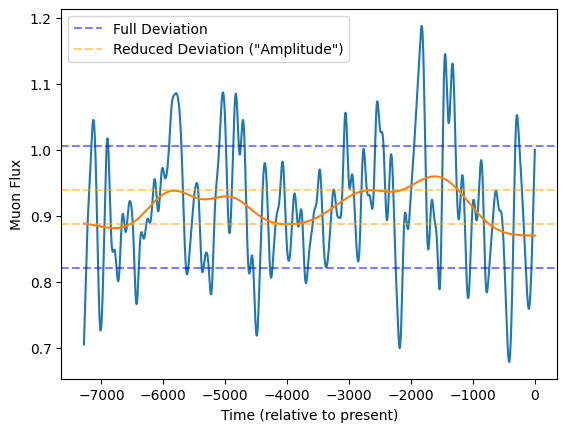

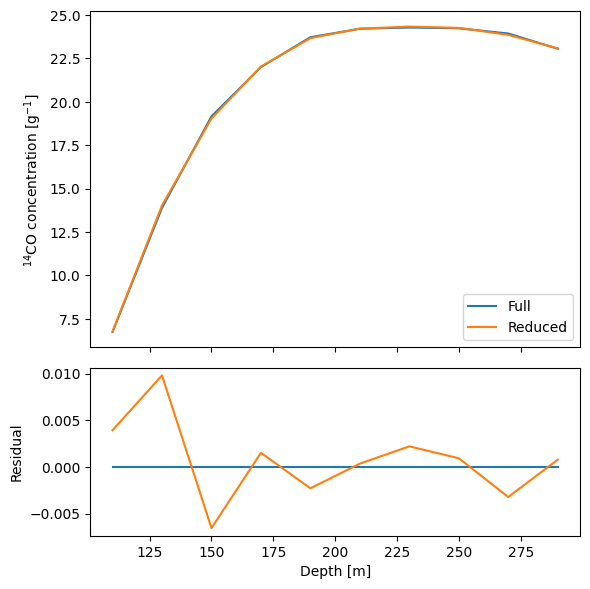

In [19]:
plt.plot(t, flux_smooth_ish)
plt.plot(t, flux_blur)

plt.axhline(np.mean(flux_smooth_ish)+np.std(flux_smooth_ish), ls='--', c='b', alpha=0.5, label='Full Deviation')
plt.axhline(np.mean(flux_smooth_ish)-np.std(flux_smooth_ish), ls='--', c='b', alpha=0.5)

plt.axhline(np.mean(flux_blur)+np.std(flux_blur), ls='--', c='orange', alpha=0.5, label='Reduced Deviation ("Amplitude")')
plt.axhline(np.mean(flux_blur)-np.std(flux_blur), ls='--', c='orange', alpha=0.5)

plt.xlabel('Time (relative to present)')
plt.ylabel('Muon Flux')
plt.legend()
plt.show()

fig, (ax1,ax2) = plt.subplots(2,1, figsize=(6,6), tight_layout=True, sharex=True, height_ratios=[2,1])

ax1.plot(Prop.z_samp, CO_smooth_ish, label='Full')
ax1.plot(Prop.z_samp, CO_blur, label='Reduced')

ax2.plot(Prop.z_samp, CO_smooth_ish / CO_smooth_ish -1)
ax2.plot(Prop.z_samp, CO_blur / CO_smooth_ish -1)

ax1.set(#xlabel='Depth [m]',
           #xscale='log',
           ylabel=r'$^{14}$CO concentration [g$^{-1}$]',
           #yscale='log',
      )
ax2.set(xlabel='Depth [m]',
           #xscale='log',
           ylabel='Residual',
           #yscale='log',
      )
#ax1.title.set_text('(Dome C)')
ax1.legend(loc='lower right')

plt.show()

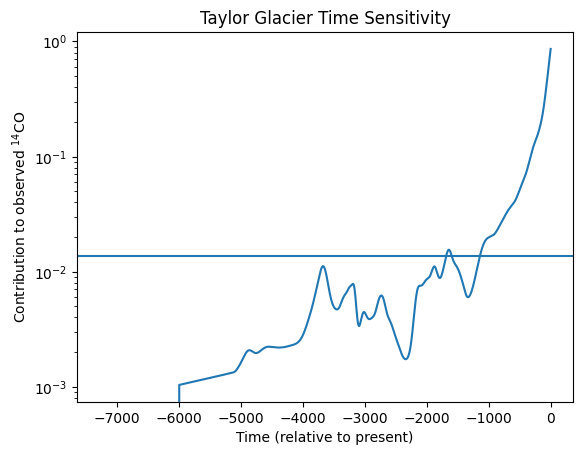

In [20]:
plt.plot(t, np.sum(CO_response_TG[0,0], axis=-1))
plt.axhline(np.sum(CO_init_TG[0,0])/1000)
plt.yscale('log')
plt.xlabel('Time (relative to present)')
plt.ylabel(r'Contribution to observed $^{14}$CO')
plt.title('Taylor Glacier Time Sensitivity')
plt.show()

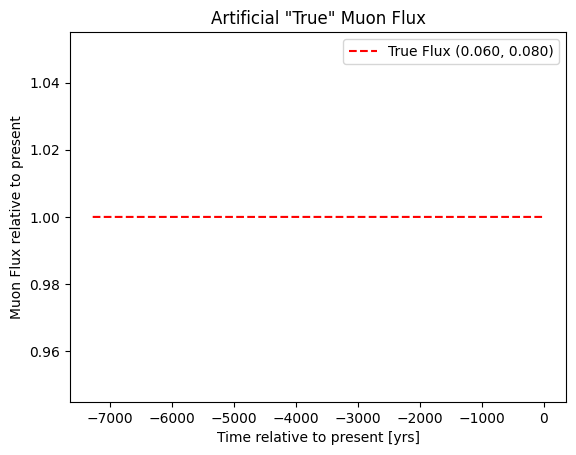

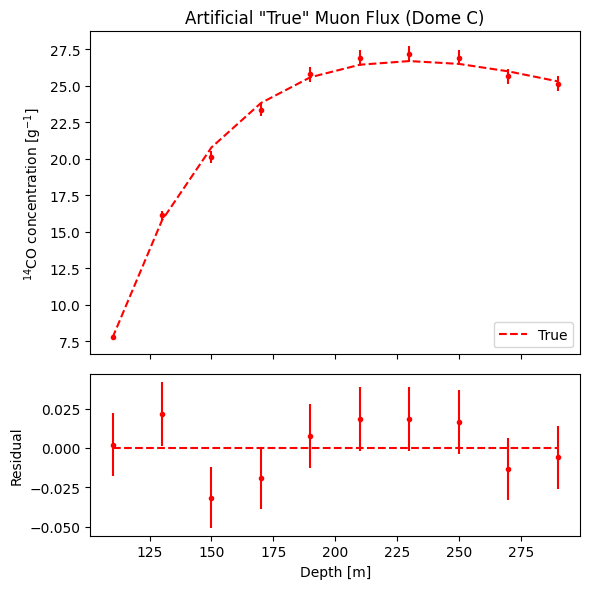

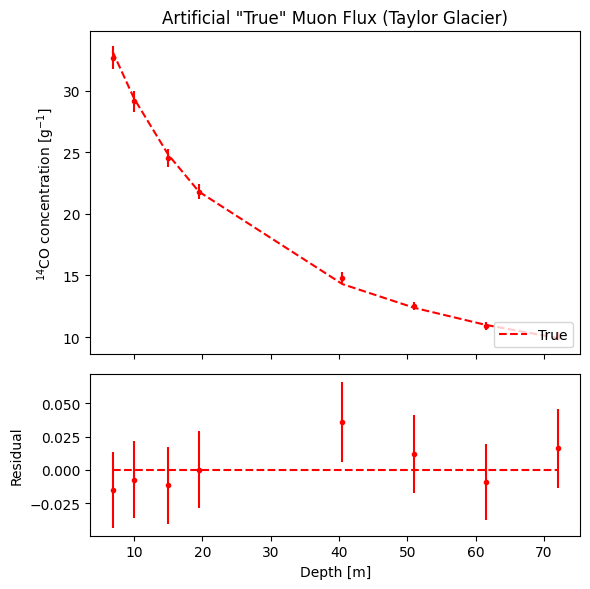

In [21]:
#N = 1
amp = 0.

rel_err = 0.02
rel_cov = 0. # correlation of experimental errors

rel_err_TG = np.mean(CO_err_TG_data/CO_exp_TG_data)
rel_cov_TG = 0.

#f_samp = np.append(np.random.normal(1.,amp*np.sqrt(N_interp)/2,(len(CO_samp)-1)), 1.)
flux_noise = np.random.normal(0., 1., (len(t)))

Smooth = np.exp(-((t.reshape((-1,1))-t.reshape((1,-1)))/(Period/10))**2/2)
Smooth /= np.sum(Smooth, axis=0, keepdims=True)

#flux_smooth = gaussian_filter(flux_noise, sigma=len(t)/10, mode='constant')
flux_smooth = flux_noise @ Smooth
#flux_true = 1 + amp*flux_smooth/np.std(gaussian_filter(flux_smooth, sigma=len(t)/20, mode='constant'))
flux_true = 1 + amp*flux_smooth/np.std(flux_smooth @ Blur)
flux_true -= flux_true[-1]-1

#flux_true = amp*t_scale + 1

CO_true = flux_true @ CO_response[0]
CO_true_TG = flux_true @ CO_response_TG[0,0] + CO_init_TG[0,0]#*flux_true[0]
# A note on the initial concentration of CO at Taylor Glacier
# The equilibrium value will be sensitive to changes in the muon flux before integration starts.
# I haven't yet thought through how to account for that, so for the moment this is ignored
CO_true_all = np.concatenate((CO_true, CO_true_TG), axis=-1)

#Sigma = np.diag(CO_err**2)
true_err = CO_true*rel_err
true_cov = np.diag(true_err**2) * (1-rel_cov) + true_err.reshape((-1,1))*true_err.reshape((1,-1)) * rel_cov
true_cov_inv = np.linalg.inv(true_cov)

true_err_TG = CO_true_TG*rel_err_TG
true_cov_TG = np.diag(true_err_TG**2) * (1-rel_cov_TG) + true_err_TG.reshape((-1,1))*true_err_TG.reshape((1,-1)) * rel_cov_TG
true_cov_inv_TG = np.linalg.inv(true_cov_TG)

#s = np.random.normal(0,rel_err,(len(Prop.z_samp)))
CO_exp = np.random.multivariate_normal(mean=CO_true, cov=true_cov)
CO_exp_TG = np.random.multivariate_normal(mean=CO_true_TG, cov=true_cov_TG)
CO_exp_all = np.concatenate((CO_exp, CO_exp_TG), axis=-1)

#CO_exp = CO_true
#CO_exp_TG = CO_true_TG
#CO_exp_all = CO_true_all

CO_err = np.abs(CO_exp * rel_err)
CO_err_TG = np.abs(CO_exp_TG * rel_err_TG)
CO_err_all = np.concatenate((CO_err, CO_err_TG), axis=-1)

#CO_exp_TG = CO_exp_TG_data
#CO_err_TG = CO_err_TG_data

rel_err_all = np.concatenate(([rel_err]*len(CO_exp), [rel_err_TG]*len(CO_exp_TG)))

Sigma = np.diag(CO_err**2) * (1-rel_cov) + CO_err.reshape((-1,1))*CO_err.reshape((1,-1)) * rel_cov
Sigma_inv = np.linalg.inv(Sigma)

Sigma_TG = np.diag(CO_err_TG**2) * (1-rel_cov_TG) + CO_err_TG.reshape((-1,1))*CO_err_TG.reshape((1,-1)) * rel_cov_TG
Sigma_inv_TG = np.linalg.inv(Sigma_TG)

Sigma_all = np.zeros((len(CO_exp_all),len(CO_exp_all)))
Sigma_all[:len(CO_exp),:len(CO_exp)] = Sigma
Sigma_all[len(CO_exp):,len(CO_exp):] = Sigma_TG
Sigma_inv_all = np.linalg.inv(Sigma_all)

plt.plot(t, flux_true, ls='--', c='r', label='True Flux ({1:.3f}, {0:.3f})'.format(*f_true))
plt.xlabel('Time relative to present [yrs]')
plt.ylabel('Muon Flux relative to present')
plt.legend()
plt.title('Artificial "True" Muon Flux')
plt.show()


fig, (ax1,ax2) = plt.subplots(2,1, figsize=(6,6), tight_layout=True, sharex=True, height_ratios=[2,1])

ax1.plot(Prop.z_samp, CO_true, ls='--', c='r', label='True')
ax1.errorbar(Prop.z_samp, CO_exp, yerr=CO_err, fmt='.', c='r')

ax2.plot(Prop.z_samp, CO_true / CO_true -1, ls='--', c='r')
ax2.errorbar(Prop.z_samp, CO_exp / CO_true -1, yerr=np.abs(CO_err/ CO_true), fmt='.', c='r')

ax1.set(#xlabel='Depth [m]',
           #xscale='log',
           ylabel=r'$^{14}$CO concentration [g$^{-1}$]',
           #yscale='log',
      )
ax2.set(xlabel='Depth [m]',
           #xscale='log',
           ylabel='Residual',
           #yscale='log',
      )
ax1.title.set_text('Artificial "True" Muon Flux (Dome C)')
ax1.legend(loc='lower right')

plt.show()


fig, (ax1,ax2) = plt.subplots(2,1, figsize=(6,6), tight_layout=True, sharex=True, height_ratios=[2,1])

ax1.plot(z_samp_TG, CO_true_TG, ls='--', c='r', label='True')
ax1.errorbar(z_samp_TG, CO_exp_TG, yerr=CO_err_TG, fmt='.', c='r')

ax2.plot(z_samp_TG, CO_true_TG / CO_true_TG -1, ls='--', c='r')
ax2.errorbar(z_samp_TG, CO_exp_TG / CO_true_TG -1, yerr=np.abs(CO_err_TG/ CO_true_TG), fmt='.', c='r')

ax1.set(#xlabel='Depth [m]',
           #xscale='log',
           ylabel=r'$^{14}$CO concentration [g$^{-1}$]',
           #yscale='log',
      )
ax2.set(xlabel='Depth [m]',
           #xscale='log',
           ylabel='Residual',
           #yscale='log',
      )
ax1.title.set_text('Artificial "True" Muon Flux (Taylor Glacier)')
ax1.legend(loc='lower right')

plt.show()

chi2_true (Dome C) = 7.715958730258375
chi2_red_true (Dome C) = 0.7715958730258375
p_true (Dome C) = 0.6565593314679015
sig_true (Dome C) = 0.4446685070933158

chi2_null (Dome C) = 7.667870178596472
chi2_red_null (Dome C) = 0.4792418861622795
p_null (Dome C) = 0.4665671409514377
sigma_null (Dome C) = 0.7280758749911532

chi2_null (Taylor Glacier) = 1.6043492456533013
chi2_red_null (Taylor Glacier) = 0.2673915409422169
p_null (Taylor Glacier) = 0.996296078030279
sigma_null (Taylor Glacier) = 0.004642194441302168

chi2_true = 10.267233535315311
chi2_red_true = 0.5704018630730728
p_true = 0.922833656828705
sig_true = 0.09686493349712459

chi2_null = 9.435679718827448
chi2_red_null = 0.5897299824267155
p_null = 0.8943930848548198
sigma_null = 0.1327474884175055



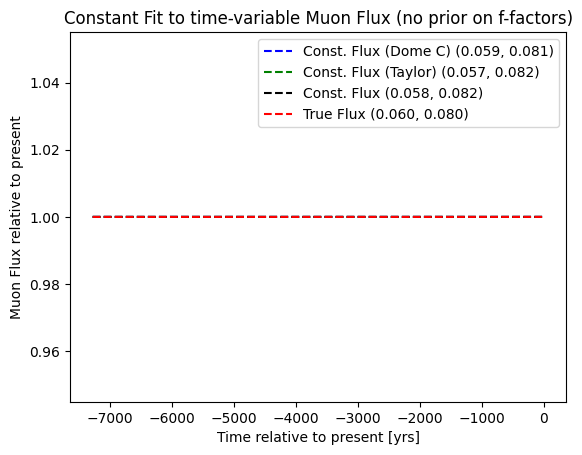

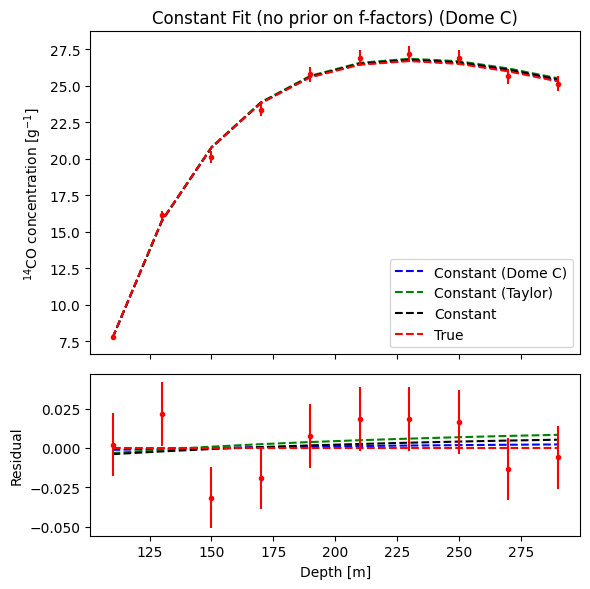

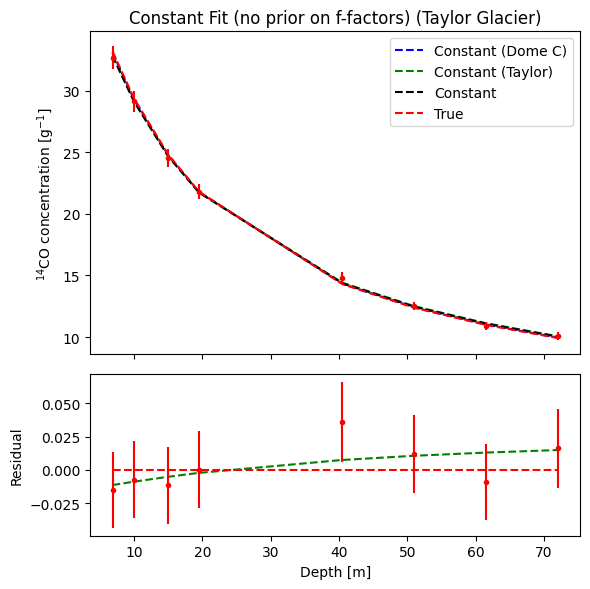

In [22]:
C0 = np.sum(C_response, axis=-2)
C0_TG = np.sum(C_response_TG, axis=-2) + C_init_TG
C0_all = np.concatenate((C0, C0_TG[0]), axis=-1)

f_hat_null = np.linalg.inv(C0 @ Sigma_inv @ T(C0)) @ C0 @ Sigma_inv @ CO_exp
f_hat_null_TG = np.linalg.inv(C0_TG @ Sigma_inv_TG @ T(C0_TG)) @ C0_TG @ Sigma_inv_TG @ CO_exp_TG
f_hat_null_all = np.linalg.inv(C0_all @ Sigma_inv_all @ T(C0_all)) @ C0_all @ Sigma_inv_all @ CO_exp_all

#chi2_true = (CO_true-CO_exp)@true_cov_inv@(CO_true-CO_exp)
chi2_true = (CO_true-CO_exp)@Sigma_inv@(CO_true-CO_exp)
p_true = stats.chi2.sf(chi2_true, len(CO_exp))
sig_true = stats.norm.isf(p_true/2.)
print('chi2_true (Dome C) = {}'.format(chi2_true))
print('chi2_red_true (Dome C) = {}'.format(chi2_true / len(CO_exp)))
print('p_true (Dome C) = {}'.format(p_true))
print('sig_true (Dome C) = {}'.format(sig_true))
print()

CO_null = np.sum(f_hat_null.reshape((*np.shape(f_hat_null),1)) * C0, axis=-2) 
chi2_null = np.sum((CO_null - CO_exp) @ Sigma_inv *(CO_null - CO_exp), axis=-1)[0]
p_null = stats.chi2.sf(chi2_null, len(CO_exp)-len(f_hat_null[0]))
sig_null = stats.norm.isf(p_null/2.)
print('chi2_null (Dome C) = {}'.format(chi2_null))
print('chi2_red_null (Dome C) = {}'.format(chi2_null / (len(CO_exp_all)-len(f_true))))
print('p_null (Dome C) = {}'.format(p_null))
print('sigma_null (Dome C) = {}'.format(sig_null))
print()

CO_null_TG = np.sum(f_hat_null_TG.reshape((*np.shape(f_hat_null_TG),1)) * C0_TG, axis=-2) 
chi2_null_TG = np.sum((CO_null_TG[0] - CO_exp_TG) @ Sigma_inv_TG *(CO_null_TG[0] - CO_exp_TG), axis=-1)[0]
p_null_TG = stats.chi2.sf(chi2_null_TG, len(CO_exp)-len(f_hat_null_TG[0]))
sig_null_TG = stats.norm.isf(p_null_TG/2.)
print('chi2_null (Taylor Glacier) = {}'.format(chi2_null_TG))
print('chi2_red_null (Taylor Glacier) = {}'.format(chi2_null_TG / (len(CO_exp_TG)-len(f_true))))
print('p_null (Taylor Glacier) = {}'.format(p_null_TG))
print('sigma_null (Taylor Glacier) = {}'.format(sig_null_TG))
print()

chi2_true_all = (CO_true_all-CO_exp_all)@Sigma_inv_all@(CO_true_all-CO_exp_all)
p_true_all = stats.chi2.sf(chi2_true_all, len(CO_exp_all))
sig_true_all = stats.norm.isf(p_true_all/2.)
print('chi2_true = {}'.format(chi2_true_all))
print('chi2_red_true = {}'.format(chi2_true_all / len(CO_exp_all)))
print('p_true = {}'.format(p_true_all))
print('sig_true = {}'.format(sig_true_all))
print()

CO_null_all = np.sum(f_hat_null_all.reshape((*np.shape(f_hat_null_all),1)) * C0_all, axis=-2) 
chi2_null_all = np.sum((CO_null_all - CO_exp_all) @ Sigma_inv_all *(CO_null_all - CO_exp_all), axis=-1)[0]
p_null_all = stats.chi2.sf(chi2_null_all, len(CO_exp_all)-len(f_true))
sig_null_all = stats.norm.isf(p_null_all/2.)
print('chi2_null = {}'.format(chi2_null_all))
print('chi2_red_null = {}'.format(chi2_null_all / (len(CO_exp_all)-len(f_true))))
print('p_null = {}'.format(p_null_all))
print('sigma_null = {}'.format(sig_null_all))
print()

plt.plot(t, t*0. + 1., ls='--', c='b', label='Const. Flux (Dome C) ({1:.3f}, {0:.3f})'.format(*f_hat_null[0]))
plt.plot(t, t*0. + 1., ls='--', c='g', label='Const. Flux (Taylor) ({1:.3f}, {0:.3f})'.format(*f_hat_null_TG[0,0]))
plt.plot(t, t*0. + 1., ls='--', c='k', label='Const. Flux ({1:.3f}, {0:.3f})'.format(*f_hat_null_all[0]))
plt.plot(t, flux_true, ls='--', c='r', label='True Flux ({1:.3f}, {0:.3f})'.format(*f_true))
plt.xlabel('Time relative to present [yrs]')
plt.ylabel('Muon Flux relative to present')
plt.legend()
plt.title('Constant Fit to time-variable Muon Flux (no prior on f-factors)')
plt.show()


fig, (ax1,ax2) = plt.subplots(2,1, figsize=(6,6), tight_layout=True, sharex=True, height_ratios=[2,1])

ax1.plot(Prop.z_samp, f_hat_null[0] @ C0[0], ls='--', c='b', label='Constant (Dome C)')
ax1.plot(Prop.z_samp, f_hat_null_TG[0,0] @ C0[0], ls='--', c='g', label='Constant (Taylor)')
ax1.plot(Prop.z_samp, f_hat_null_all[0] @ C0[0], ls='--', c='k', label='Constant')
ax1.plot(Prop.z_samp, CO_true, ls='--', c='r', label='True')
ax1.errorbar(Prop.z_samp, CO_exp, yerr=CO_err, fmt='.', c='r')

ax2.plot(Prop.z_samp, f_hat_null[0] @ C0[0] / CO_true -1, ls='--', c='b')
ax2.plot(Prop.z_samp, f_hat_null_TG[0,0] @ C0[0] / CO_true -1, ls='--', c='g')
ax2.plot(Prop.z_samp, f_hat_null_all[0] @ C0[0] / CO_true -1, ls='--', c='k')
ax2.plot(Prop.z_samp, CO_true / CO_true -1, ls='--', c='r')
ax2.errorbar(Prop.z_samp, CO_exp / CO_true -1, yerr=np.abs(CO_err/ CO_true), fmt='.', c='r')

ax1.set(#xlabel='Depth [m]',
           #xscale='log',
           ylabel=r'$^{14}$CO concentration [g$^{-1}$]',
           #yscale='log',
      )
ax2.set(xlabel='Depth [m]',
           #xscale='log',
           ylabel='Residual',
           #yscale='log',
      )
ax1.title.set_text('Constant Fit (no prior on f-factors) (Dome C)')
ax1.legend(loc='lower right')

plt.show()


fig, (ax1,ax2) = plt.subplots(2,1, figsize=(6,6), tight_layout=True, sharex=True, height_ratios=[2,1])

ax1.plot(z_samp_TG, f_hat_null[0] @ C0_TG[0,0], ls='--', c='b', label='Constant (Dome C)')
ax1.plot(z_samp_TG, f_hat_null_TG[0,0] @ C0_TG[0,0], ls='--', c='g', label='Constant (Taylor)')
ax1.plot(z_samp_TG, f_hat_null_all[0] @ C0_TG[0,0], ls='--', c='k', label='Constant')
ax1.plot(z_samp_TG, CO_true_TG, ls='--', c='r', label='True')
ax1.errorbar(z_samp_TG, CO_exp_TG, yerr=CO_err_TG, fmt='.', c='r')

#ax2.plot(z_samp_TG, f_hat_null[0] @ C0_TG[0,0] / CO_true_TG -1, ls='--', c='b')
ax2.plot(z_samp_TG, f_hat_null_TG[0,0] @ C0_TG[0,0] / CO_true_TG -1, ls='--', c='g')
#ax2.plot(z_samp_TG, f_hat_null_all[0] @ C0_TG[0,0] / CO_true_TG -1, ls='--', c='k')
ax2.plot(z_samp_TG, CO_true_TG / CO_true_TG -1, ls='--', c='r')
ax2.errorbar(z_samp_TG, CO_exp_TG / CO_true_TG -1, yerr=np.abs(CO_err_TG/ CO_true_TG), fmt='.', c='r')

ax1.set(#xlabel='Depth [m]',
           #xscale='log',
           ylabel=r'$^{14}$CO concentration [g$^{-1}$]',
           #yscale='log',
      )
ax2.set(xlabel='Depth [m]',
           #xscale='log',
           ylabel='Residual',
           #yscale='log',
      )
ax1.title.set_text('Constant Fit (no prior on f-factors) (Taylor Glacier)')
ax1.legend(loc='upper right')

plt.show()

In [23]:
Response = T(np.swapaxes(f_unit @ C_step, -2, -3))
Response_TG = T(np.swapaxes(f_unit @ C_step_TG, -2, -3))
Response_TG[:,:,:,:,-1] += f_unit @ C_init_TG# contribution from starting equilibrium 14CO proportional to f-factors (present day)
Response_all = np.concatenate((Response, Response_TG[0]), axis=-2)

unfold_results = [pu.iterative_unfold(
    data = CO_exp_all,
    data_err = CO_err_all,
    response = R,
    response_err = np.sqrt(abs(R))*0.,
    efficiencies = np.sum(R,axis=0),
    efficiencies_err = np.sum(R,axis=0)*0.,
    #callbacks=[pu.Logger()],
    ts_stopping = 0.001) for R in tqdm(Response_all[0])]

100%|███████████████████████████████████████████████████████████████████████████████████| 21/21 [00:02<00:00,  7.91it/s]


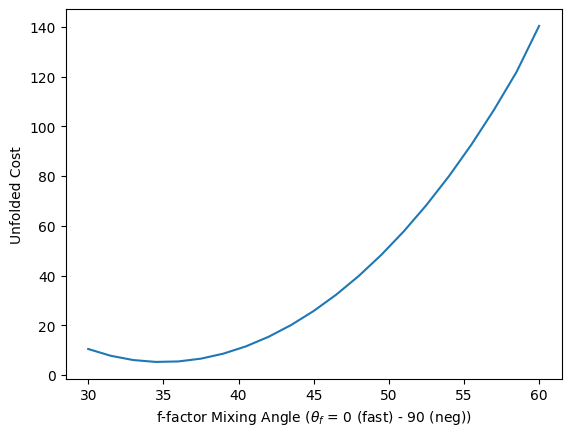

In [24]:
# chi^2 as cost
chi2_u = np.array([(Response_all[0,i] @ u['unfolded'] - CO_exp_all) @ Sigma_inv_all @ (Response_all[0,i] @ u['unfolded'] - CO_exp_all) for i,u in enumerate(unfold_results)])
cost_u = chi2_u

# standard deviation as cost
#cost_u = np.array([np.std(u['unfolded']) for i,u in enumerate(unfold_results)])

i_f_u = np.argmin(cost_u)
f_u = f_unit[i_f_u]
u = unfold_results[i_f_u]
R = Response[0,i_f_u]
R_TG = Response_TG[0,0,i_f_u]
R_all = Response_all[0,i_f_u]

plt.plot(theta_f*180/np.pi, cost_u)
plt.xlabel(r'f-factor Mixing Angle ($\theta_f$ = 0 (fast) - 90 (neg))')
plt.ylabel('Unfolded Cost')
plt.show()

chi2_true = 10.267233535315311
chi2_red_true = 0.5704018630730728
p_true = 0.922833656828705
sig_true = 0.09686493349712459

chi2_null = 9.435679718827448
chi2_red_null = 0.5897299824267155
p_null = 0.8943930848548198
sigma_null = 0.1327474884175055

chi2_unfold = 5.267316919834651


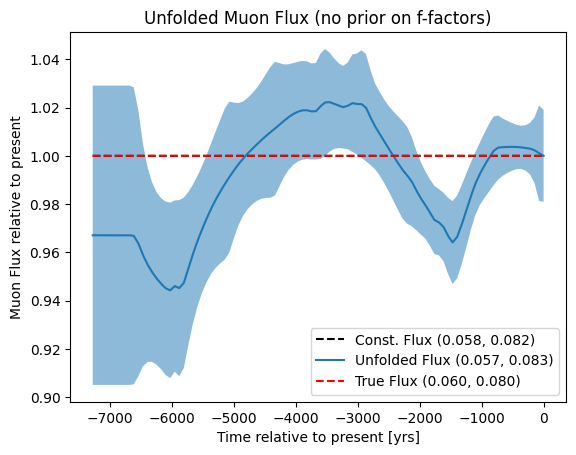

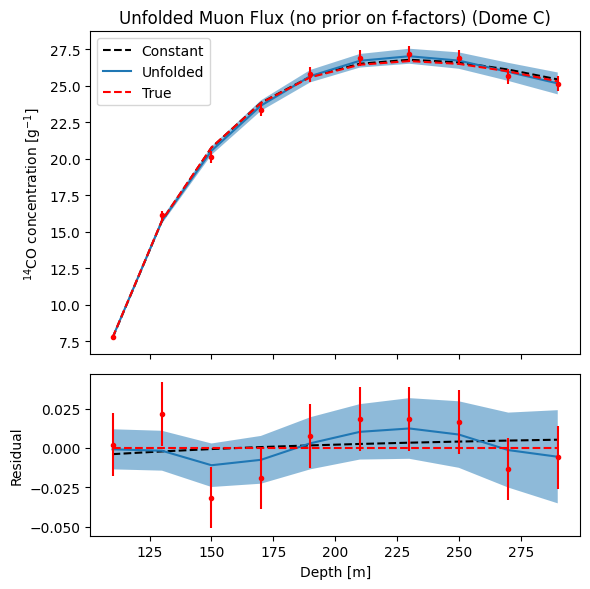

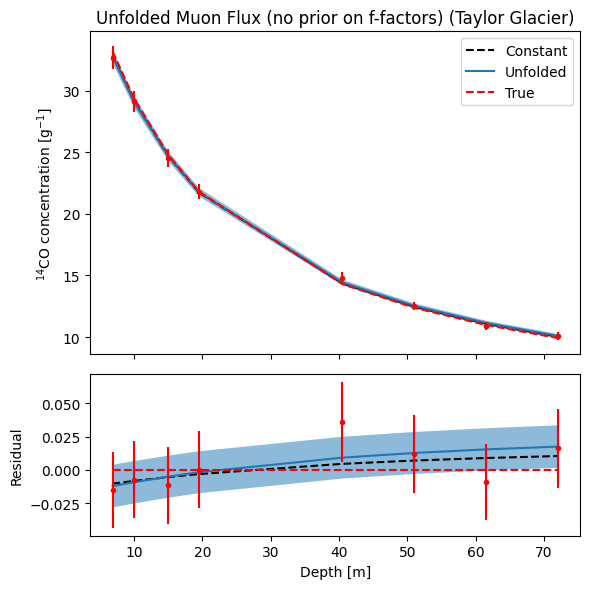

In [25]:
print('chi2_true = {}'.format(chi2_true_all))
print('chi2_red_true = {}'.format(chi2_true_all / len(CO_exp_all)))
print('p_true = {}'.format(p_true_all))
print('sig_true = {}'.format(sig_true_all))
print()

print('chi2_null = {}'.format(chi2_null_all))
print('chi2_red_null = {}'.format(chi2_null_all / (len(CO_exp_all)-len(f_true))))
print('p_null = {}'.format(p_null_all))
print('sigma_null = {}'.format(sig_null_all))
print()

print('chi2_unfold = {}'.format((chi2_u[i_f_u])))

#f_pred = flux_true

#c_pred = CO_true
z = Prop.z[Prop.i_start:]
z_samp = Prop.z_samp

plt.plot(t, t*0. + 1., ls='--', c='k', label='Const. Flux ({1:.3f}, {0:.3f})'.format(*f_hat_null_all[0]))
#plt.plot(t, u['unfolded'] @ f_step)
u_err = np.sqrt(u['stat_err']**2 + np.nan_to_num(u['sys_err'])**2)
plt.fill_between(t, (u['unfolded']- u_err) @ f_step / (u['unfolded'] @ f_step)[-1], (u['unfolded']+ u_err) @ f_step / (u['unfolded'] @ f_step)[-1], alpha=0.5)
plt.plot(t, u['unfolded'] @ f_step / (u['unfolded'] @ f_step)[-1], label='Unfolded Flux ({1:.3f}, {0:.3f})'.format(*(f_u*u['unfolded'][-1])))
plt.plot(t, flux_true, ls='--', c='r', label='True Flux ({1:.3f}, {0:.3f})'.format(*f_true))

plt.ylabel('Muon Flux relative to present')
plt.xlabel('Time relative to present [yrs]')
plt.title('Unfolded Muon Flux (no prior on f-factors)')
plt.legend()

plt.show()

fig, (ax1,ax2) = plt.subplots(2,1, figsize=(6,6), tight_layout=True, sharex=True, height_ratios=[2,1])

ax1.plot(Prop.z_samp, f_hat_null_all[0] @ C0[0], ls='--', c='k', label='Constant')
ax2.plot(Prop.z_samp, f_hat_null_all[0] @ C0[0] / CO_true -1, ls='--', c='k')

u_err = np.sqrt(u['stat_err']**2 + np.nan_to_num(u['sys_err'])**2)
ax1.fill_between(z_samp, R @ (u['unfolded']-u_err), R @ (u['unfolded']+u_err), alpha=0.5)
ax2.fill_between(z_samp, R @ (u['unfolded']-u_err)  / CO_true -1, R @ (u['unfolded']+u_err)  / CO_true -1, alpha=0.5)
ax1.plot(z_samp, R @ u['unfolded'], label='Unfolded')
ax2.plot(z_samp, R @ u['unfolded'] / CO_true -1)
ax1.errorbar(z_samp, CO_exp, yerr=CO_err, fmt='.', c='r')
ax2.errorbar(z_samp, CO_exp / CO_true -1, yerr=CO_err /CO_true, fmt='.', c='r')

ax1.plot(z_samp, CO_true, ls='--', c='r', label='True')
ax2.plot(z_samp, CO_true/CO_true -1, ls='--', c='r')

ax1.set(#xlabel='Depth [m]',
           #xscale='log',
           ylabel=r'$^{14}$CO concentration [g$^{-1}$]',
           #yscale='log',
      )
ax2.set(xlabel='Depth [m]',
           #xscale='log',
           ylabel='Residual',
           #yscale='log',
      )
ax1.title.set_text('Unfolded Muon Flux (no prior on f-factors) (Dome C)')
ax1.legend()

plt.show()


fig, (ax1,ax2) = plt.subplots(2,1, figsize=(6,6), tight_layout=True, sharex=True, height_ratios=[2,1])

ax1.plot(z_samp_TG, f_hat_null_all[0] @ C0_TG[0,0], ls='--', c='k', label='Constant')
ax2.plot(z_samp_TG, f_hat_null_all[0] @ C0_TG[0,0] / CO_true_TG -1, ls='--', c='k')

u_err = np.sqrt(u['stat_err']**2 + np.nan_to_num(u['sys_err'])**2)
ax1.fill_between(z_samp_TG, R_TG @ (u['unfolded']-u_err), R_TG @ (u['unfolded']+u_err), alpha=0.5)
ax2.fill_between(z_samp_TG, R_TG @ (u['unfolded']-u_err)  / CO_true_TG -1, R_TG @ (u['unfolded']+u_err)  / CO_true_TG -1, alpha=0.5)
ax1.plot(z_samp_TG, R_TG @ u['unfolded'], label='Unfolded')
ax2.plot(z_samp_TG, R_TG @ u['unfolded'] / CO_true_TG -1)
ax1.errorbar(z_samp_TG, CO_exp_TG, yerr=CO_err_TG, fmt='.', c='r')
ax2.errorbar(z_samp_TG, CO_exp_TG / CO_true_TG -1, yerr=CO_err_TG /CO_true_TG, fmt='.', c='r')

ax1.plot(z_samp_TG, CO_true_TG, ls='--', c='r', label='True')
ax2.plot(z_samp_TG, CO_true_TG/CO_true_TG -1, ls='--', c='r')

ax1.set(#xlabel='Depth [m]',
           #xscale='log',
           ylabel=r'$^{14}$CO concentration [g$^{-1}$]',
           #yscale='log',
      )
ax2.set(xlabel='Depth [m]',
           #xscale='log',
           ylabel='Residual',
           #yscale='log',
      )
ax1.title.set_text('Unfolded Muon Flux (no prior on f-factors) (Taylor Glacier)')
ax1.legend()

plt.show()

In [26]:
a_max = 0.02
da = 0.0005
a = np.arange(-a_max, a_max+da, da)

CO_0 = np.reshape(f_unit @ C0, (-1, 1, 1, 1, len(f_unit), len(CO_exp)))
CO_0_TG = np.reshape(f_unit @ C0_TG, (-1, 1, 1, 1, len(f_unit), len(CO_exp_TG)))
CO_0_all = np.reshape(f_unit @ C0_all, (-1, 1, 1, 1, len(f_unit), len(CO_exp_all)))
CO_gauss = f_unit @ np.expand_dims(C_gauss, axis=1) * a.reshape((1,-1,1,1,1,1))
CO_gauss_TG = f_unit @ np.expand_dims(C_gauss_TG, axis=1) * a.reshape((1,-1,1,1,1,1))
CO_gauss_all = f_unit @ np.expand_dims(C_gauss_all, axis=1) * a.reshape((1,-1,1,1,1,1))
# axis0 - production model
# axis1 - amplitude
# axis2 - center
# axis3 - width
# axis4 - theta_f (f_factor mixing angle)
# axis5 - sample depth

f_hat = (np.sum(CO_0_all @ Sigma_inv_all * (CO_exp_all.reshape((1,1,1,1,1,-1)) - CO_gauss_all), axis=-1) / np.sum(CO_0_all @ Sigma_inv_all * CO_0_all, axis=-1)).clip(min=0.)
CO_pred = np.expand_dims(f_hat,-1) * CO_0 + CO_gauss
CO_pred_TG = np.expand_dims(f_hat,-1) * CO_0_TG + CO_gauss_TG
CO_pred_all = np.expand_dims(f_hat,-1) * CO_0_all + CO_gauss_all

In [27]:
chi2 = np.sum((CO_pred_all - CO_exp_all) @ Sigma_inv_all *(CO_pred_all - CO_exp_all), axis=-1)

#chi2_c = np.min(chi2, axis=(0,-2))
#chi2_c = np.min(chi2[:,:,:,0], axis=(0))
p = stats.chi2.sf(chi2, len(CO_exp_all)-5)
sig = stats.norm.isf(p/2.)
L = np.exp(-chi2/2) / np.sqrt(np.linalg.det(2*np.pi*Sigma_all))
P = np.mean(L, axis=(0,-2,-1))

amplitude: -0.0019999999999999844
center: -1583.0
width: 100.0

chi2_true = 10.267233535315311
chi2_red_true = 0.5704018630730728
p_true = 0.922833656828705
sig_true = 0.09686493349712459

chi2_null = 9.435679718827448
chi2_red_null = 0.5897299824267155
p_null = 0.8943930848548198
sigma_null = 0.1327474884175055

chi2_unfold = 5.267316919834651

chi2_gauss = 6.265557775722649
chi2_red_gauss = 0.4819659827478961
p_gauss = 0.9359515985792471
sigma_gauss = 0.08035917111067321



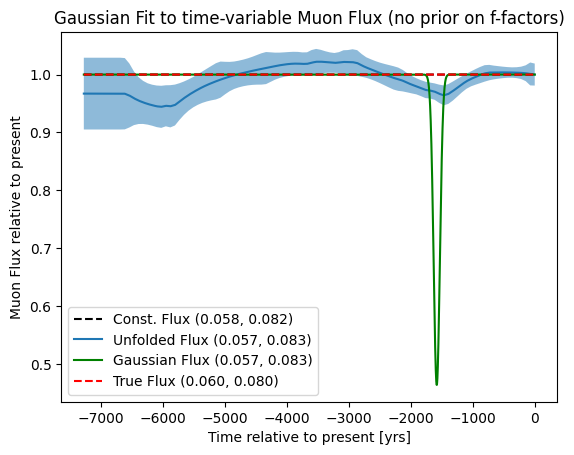

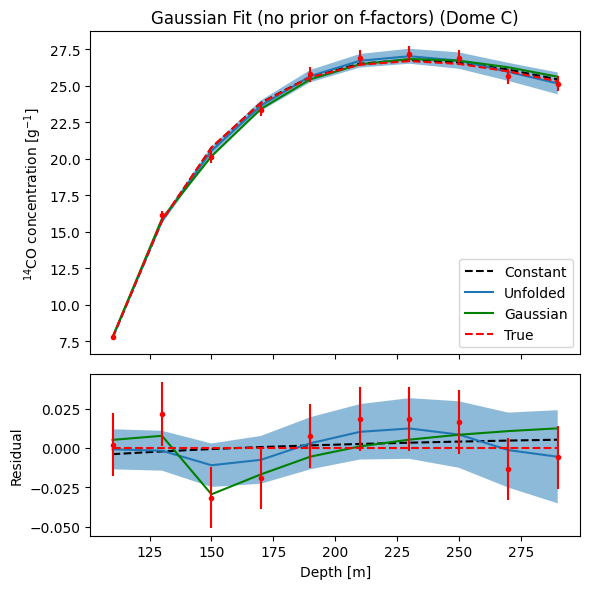

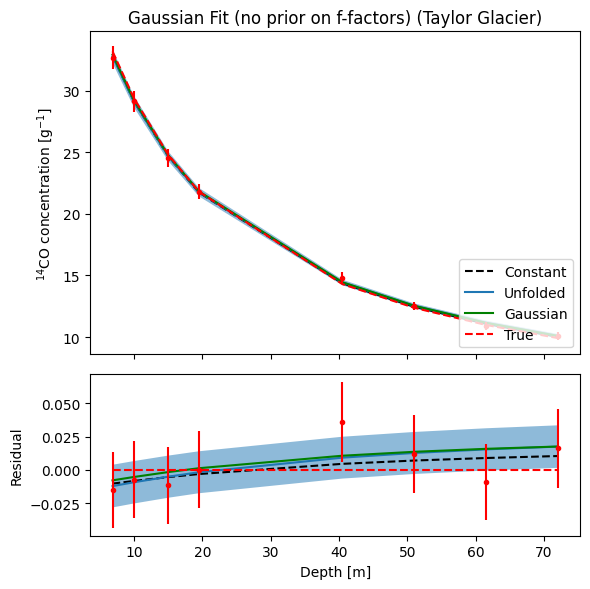

In [28]:
i_p, i_a, i_c, i_w, i_f = np.unravel_index(chi2.argmin(), chi2.shape)

#i_a = 0
print('amplitude: {}'.format(a[i_a]))
#i_c = -1
print('center: {}'.format(gauss_centers[i_c]))
#i_w = 10
print('width: {}'.format(gauss_widths[i_w]))
print()

print('chi2_true = {}'.format(chi2_true_all))
print('chi2_red_true = {}'.format(chi2_true_all / len(CO_exp_all)))
print('p_true = {}'.format(p_true_all))
print('sig_true = {}'.format(sig_true_all))
print()

print('chi2_null = {}'.format(chi2_null_all))
print('chi2_red_null = {}'.format(chi2_null_all / (len(CO_exp_all)-len(f_true))))
print('p_null = {}'.format(p_null_all))
print('sigma_null = {}'.format(sig_null_all))
print()

print('chi2_unfold = {}'.format((chi2_u[i_f_u])))
print()

print('chi2_gauss = {}'.format(chi2[i_p,i_a,i_c,i_w,i_f]))
print('chi2_red_gauss = {}'.format(chi2[i_p,i_a,i_c,i_w,i_f] / (len(CO_exp_all)-5)))
print('p_gauss = {}'.format(p[i_p,i_a,i_c,i_w,i_f]))
print('sigma_gauss = {}'.format(sig[i_p,i_a,i_c,i_w,i_f]))
print()

plt.plot(t, t*0. + 1., ls='--', c='k', label='Const. Flux ({1:.3f}, {0:.3f})'.format(*(f_hat_null_all[i_p])))
#plt.plot(t, t*0. + 1., ls='--', c='k', label='Const. Flux ({:.1f} deg.)'.format(np.arctan(f_hat_null[i_p,1]/f_hat_null[i_p,0])*180/np.pi))

#plt.plot(t, u['unfolded'] @ f_step)
u_err = np.sqrt(u['stat_err']**2 + np.nan_to_num(u['sys_err'])**2)
plt.fill_between(t, (u['unfolded']- u_err) @ f_step / (u['unfolded'] @ f_step)[-1], (u['unfolded']+ u_err) @ f_step / (u['unfolded'] @ f_step)[-1], alpha=0.5)
plt.plot(t, u['unfolded'] @ f_step / (u['unfolded'] @ f_step)[-1], label='Unfolded Flux ({1:.3f}, {0:.3f})'.format(*(f_u*u['unfolded'][-1])))
#plt.plot(t, u['unfolded'] @ f_step / (u['unfolded'] @ f_step)[-1], label='Unfolded Flux ({:.1f} deg.)'.format(np.arctan(f_u[1]/f_u[0])*180/np.pi))

plt.plot(t, (f_hat[i_p,i_a,i_c,i_w,i_f]+a[i_a]*f_gauss[i_c,i_w]) / (f_hat[i_p,i_a,i_c,i_w,i_f]+a[i_a]*f_gauss[i_c,i_w])[-1], label='Gaussian Flux ({1:.3f}, {0:.3f})'.format(*(f_unit[i_f]*(f_hat[i_p,i_a,i_c,i_w,i_f]+a[i_a]*f_gauss[i_c,i_w])[-1])), c='g')
#plt.plot(t, (f_hat[i_p,i_a,i_c,i_w,i_f]+a[i_a]*f_gauss[i_c,i_w]) / (f_hat[i_p,i_a,i_c,i_w,i_f]+a[i_a]*f_gauss[i_c,i_w])[-1], label='Gaussian Flux ({:.1f} deg.)'.format(np.arctan(f_unit[i_f,1]/f_unit[i_f,0])*180/np.pi), c='g')
plt.plot(t, flux_true, ls='--', c='r', label='True Flux ({1:.3f}, {0:.3f})'.format(*f_true))
#plt.plot(t,f_samp @ f_interp / (f_samp @ f_interp)[-1], ls='--', c='r', label='True Flux ({:.1f} deg.)'.format(np.arctan(f_true[1]/f_true[0])*180/np.pi))
plt.xlabel('Time relative to present [yrs]')
plt.ylabel('Muon Flux relative to present')
plt.legend()
plt.title('Gaussian Fit to time-variable Muon Flux (no prior on f-factors)')
plt.show()


fig, (ax1,ax2) = plt.subplots(2,1, figsize=(6,6), tight_layout=True, sharex=True, height_ratios=[2,1])

ax1.plot(Prop.z_samp, f_hat_null_all[0] @ C0[0], ls='--', c='k', label='Constant')

ax2.plot(Prop.z_samp, f_hat_null_all[0] @ C0[0] / CO_true -1, ls='--', c='k')

u_err = np.sqrt(u['stat_err']**2 + np.nan_to_num(u['sys_err'])**2)
ax1.fill_between(z_samp, R @ (u['unfolded']-u_err), R @ (u['unfolded']+u_err), alpha=0.5)
ax2.fill_between(z_samp, R @ (u['unfolded']-u_err)/ CO_true -1, R @ (u['unfolded']+u_err) / CO_true -1, alpha=0.5)
ax1.plot(z_samp, R @ u['unfolded'], label='Unfolded')
ax2.plot(z_samp, R @ u['unfolded'] / CO_true -1)

    
ax1.plot(Prop.z_samp, CO_pred[i_p,i_a,i_c,i_w,i_f], label='Gaussian', c='g')
ax1.plot(Prop.z_samp, CO_true, ls='--', c='r', label='True')
ax1.errorbar(Prop.z_samp, CO_exp, yerr=CO_err, fmt='.', c='r')

ax2.plot(Prop.z_samp, CO_pred[i_p,i_a,i_c,i_w,i_f] / CO_true -1, c='g')
ax2.plot(Prop.z_samp, CO_true / CO_true -1, ls='--', c='r')
ax2.errorbar(Prop.z_samp, CO_exp / CO_true -1, yerr=CO_err/ CO_true, fmt='.', c='r')

ax1.set(#xlabel='Depth [m]',
           #xscale='log',
           ylabel=r'$^{14}$CO concentration [g$^{-1}$]',
           #yscale='log',
      )
ax2.set(xlabel='Depth [m]',
           #xscale='log',
           ylabel='Residual',
           #yscale='log',
      )
ax1.title.set_text('Gaussian Fit (no prior on f-factors) (Dome C)')
ax1.legend(loc='lower right')

plt.show()


fig, (ax1,ax2) = plt.subplots(2,1, figsize=(6,6), tight_layout=True, sharex=True, height_ratios=[2,1])

ax1.plot(z_samp_TG, f_hat_null_all[0] @ C0_TG[0,0], ls='--', c='k', label='Constant')

ax2.plot(z_samp_TG, f_hat_null_all[0] @ C0_TG[0,0] / CO_true_TG -1, ls='--', c='k')

u_err = np.sqrt(u['stat_err']**2 + np.nan_to_num(u['sys_err'])**2)
ax1.fill_between(z_samp_TG, R_TG @ (u['unfolded']-u_err), R_TG @ (u['unfolded']+u_err), alpha=0.5)
ax2.fill_between(z_samp_TG, R_TG @ (u['unfolded']-u_err)/ CO_true_TG -1, R_TG @ (u['unfolded']+u_err) / CO_true_TG -1, alpha=0.5)
ax1.plot(z_samp_TG, R_TG @ u['unfolded'], label='Unfolded')
ax2.plot(z_samp_TG, R_TG @ u['unfolded'] / CO_true_TG -1)

    
ax1.plot(z_samp_TG, CO_pred_TG[0,i_p,i_a,i_c,i_w,i_f], label='Gaussian', c='g')
ax1.plot(z_samp_TG, CO_true_TG, ls='--', c='r', label='True')
ax1.errorbar(z_samp_TG, CO_exp_TG, yerr=CO_err_TG, fmt='.', c='r')

ax2.plot(z_samp_TG, CO_pred_TG[0,i_p,i_a,i_c,i_w,i_f] / CO_true_TG -1, c='g')
ax2.plot(z_samp_TG, CO_true_TG / CO_true_TG -1, ls='--', c='r')
ax2.errorbar(z_samp_TG, CO_exp_TG / CO_true_TG -1, yerr=CO_err_TG/ CO_true_TG, fmt='.', c='r')

ax1.set(#xlabel='Depth [m]',
           #xscale='log',
           ylabel=r'$^{14}$CO concentration [g$^{-1}$]',
           #yscale='log',
      )
ax2.set(xlabel='Depth [m]',
           #xscale='log',
           ylabel='Residual',
           #yscale='log',
      )
ax1.title.set_text('Gaussian Fit (no prior on f-factors) (Taylor Glacier)')
ax1.legend(loc='lower right')

plt.show()

True Amplitude: 	0.0000
Best Fit Amplitude: 	0.0020


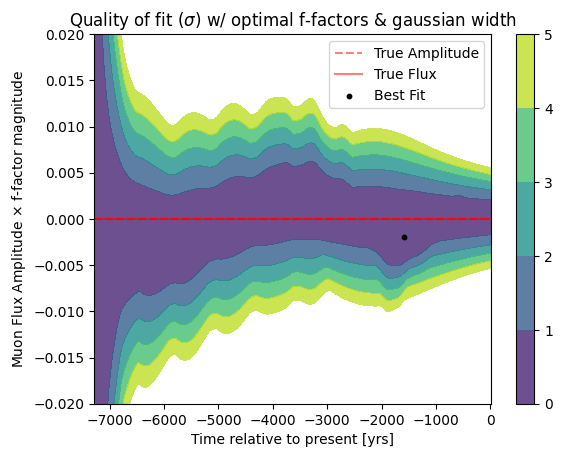

In [29]:
amp_true = np.std(gaussian_filter(flux_true, sigma=(t_bins[-1]-t_bins[0])/20))*np.sqrt(np.sum(f_true**2))

print('True Amplitude: \t{:.4f}'.format(amp_true))
print('Best Fit Amplitude: \t{:.4f}'.format(np.std(gaussian_filter(f_hat[i_p,i_a,i_c,i_w,i_f]+a[i_a]*f_gauss[i_c,i_w], sigma=(t_bins[-1]-t_bins[0])/20))))

sig_plot = np.min(sig,axis=(0,-2,-1))
sig_plot[a==0.] = sig_null

plt.contourf(gauss_centers, a, sig_plot, alpha=0.8, levels=np.arange(6))
plt.colorbar()
plt.axhline(amp_true, ls='--', c='r', alpha=0.5, label='True Amplitude')
plt.axhline(-amp_true, ls='--', c='r', alpha=0.5)
plt.plot(t, (flux_true-np.mean(flux_true))*np.sqrt(np.sum(f_true**2)), c='r', alpha=0.5, label='True Flux')
#plt.plot(t, (gaussian_filter(flux_true, sigma=len(t)/20)-np.mean(flux_true))*np.sqrt(np.sum(f_true**2)), c='r', alpha=0.5, label='True Flux')
#plt.plot(t, (flux_true @ Blur-np.mean(flux_true))*np.sqrt(np.sum(f_true**2)), c='r', alpha=0.5, label='True Flux')

plt.scatter(gauss_centers[i_c], a[i_a], c='k', s=10, label='Best Fit')
plt.xlabel('Time relative to present [yrs]')
plt.ylabel(r'Muon Flux Amplitude $\times$ f-factor magnitude')
plt.title(r'Quality of fit ($\sigma$) w/ optimal f-factors & gaussian width')
plt.legend()
plt.show()

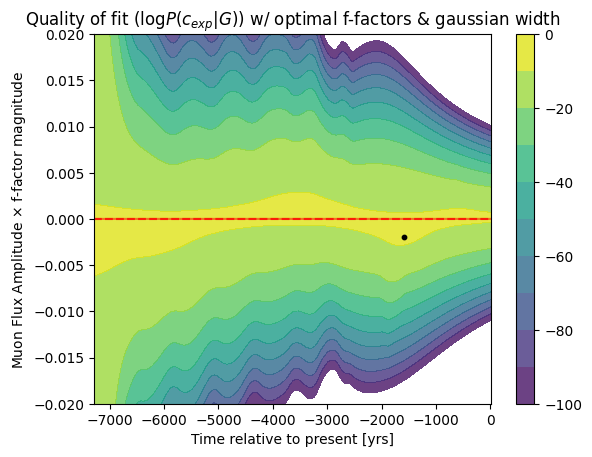

In [30]:
plt.contourf(gauss_centers, a, np.log(P), alpha=0.8, levels=np.arange(-100,10,10))
plt.colorbar()
plt.axhline(amp_true, ls='--', c='r', alpha=0.5, label='True Amplitude')
plt.axhline(-amp_true, ls='--', c='r', alpha=0.5)
plt.plot(t, (flux_true-np.mean(flux_true))*np.sqrt(np.sum(f_true**2)), c='r', alpha=0.5, label='True Flux')
#plt.plot(t, (gaussian_filter(flux_true, sigma=len(t)/20)-np.mean(flux_true))*np.sqrt(np.sum(f_true**2)), c='r', alpha=0.5, label='True Flux')
#plt.plot(t, (flux_true @ Blur-np.mean(flux_true))*np.sqrt(np.sum(f_true**2)), c='r', alpha=0.5, label='True Flux')

plt.scatter(gauss_centers[i_c], a[i_a], c='k', s=10, label='Best Fit')

plt.xlabel('Time relative to present [yrs]')
plt.ylabel(r'Muon Flux Amplitude $\times$ f-factor magnitude')
plt.title(r'Quality of fit (log$P(c_{exp}|G)$) w/ optimal f-factors & gaussian width')
plt.show()

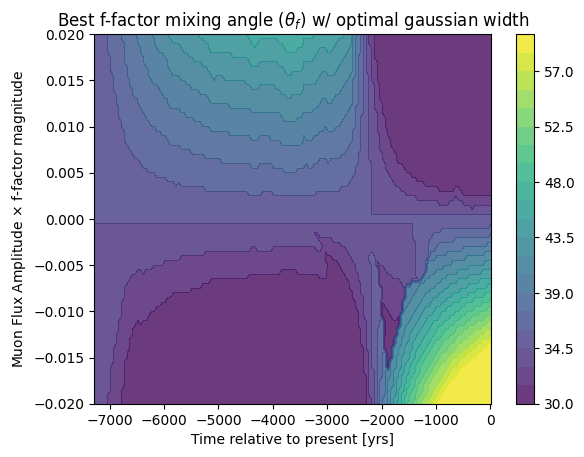

In [31]:
plt.contourf(gauss_centers, a, theta_f[np.argmin(np.min(chi2, axis=(0,-2)), axis=-1)]*180/np.pi, alpha=0.8, levels=theta_f*180/np.pi)
plt.colorbar()
plt.xlabel('Time relative to present [yrs]')
plt.ylabel(r'Muon Flux Amplitude $\times$ f-factor magnitude')
plt.title(r'Best f-factor mixing angle ($\theta_f$) w/ optimal gaussian width')
plt.show()

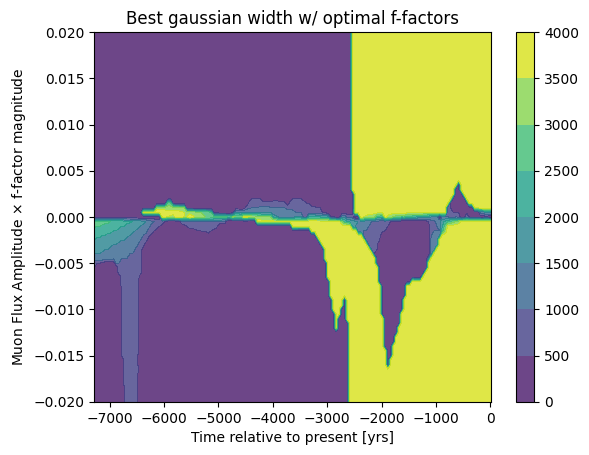

In [32]:
plt.contourf(gauss_centers, a, gauss_widths[np.argmin(np.min(chi2, axis=(0,-1)), axis=-1)], alpha=0.8)
plt.colorbar()
plt.xlabel('Time relative to present [yrs]')
plt.ylabel(r'Muon Flux Amplitude $\times$ f-factor magnitude')
plt.title(r'Best gaussian width w/ optimal f-factors')
plt.show()

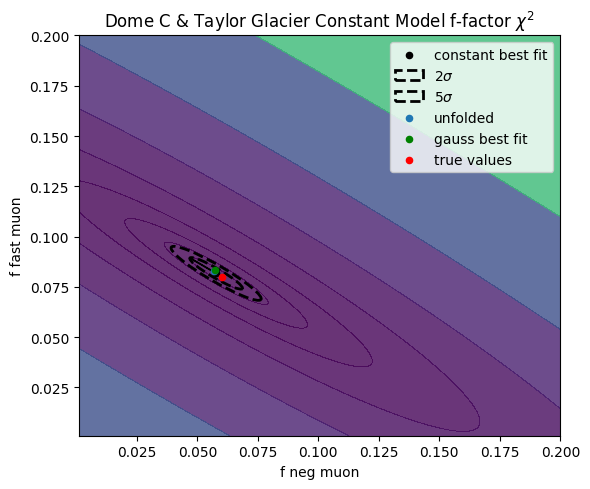

In [33]:
# Same as above, but with f_neg on the x-axis

from matplotlib.patches import Ellipse

C = C0_all[0].T
Sigma_f_inv = C.T @ Sigma_inv_all @ C
Sigma_f = np.linalg.inv(Sigma_f_inv)
f_var, f_vec = np.linalg.eig(Sigma_f)

C_exp = CO_exp_all

f = f_hat_null_all[0]
f_prime = f + f_vec[:,0]*np.sqrt(f_var[0])*0.

# make eigenvectors point up (looks nice on plot)
f_vec[:,0] *= -1. if f_vec[0,0]<0. else 1.
f_vec[:,1] *= -1. if f_vec[0,1]<0. else 1.

fig, ax = plt.subplots(1,1, figsize=(6,5), tight_layout=True, sharex=True)

chi2_best = (C@f_prime-C_exp).T@Sigma_inv_all@(C@f_prime-C_exp)
sig1_dist = np.sqrt(stats.chi2.isf(stats.norm.sf(2.)*2., len(C_exp)-len(f)) - chi2_best)

w = 0.02
df = 0.001
#f0_grid = np.arange(f[0]-w, f[0]+w+df, df)
#f1_grid = np.arange(f[1]-w, f[1]+w+df, df)
f0_grid = np.arange(df, 0.2+df, df)
f1_grid = np.arange(df, 0.2+df, df)
f_grid = np.flip(np.array(np.meshgrid(f1_grid, f0_grid)), axis=0).swapaxes(0,1)
chi2_grid = np.sum( (C@f_grid-(C_exp).reshape((1,-1,1))) * (Sigma_inv_all@(C@f_grid-(C_exp).reshape((1,-1,1)))), axis=1)

# chi2 without errors
#chi2_grid = np.sum( (C@f_grid-(C_exp-C_n[i,0,0]*f_n).reshape((1,-1,1)))**2 /(C@f_grid + (C_n[i,0,0]*f_n).reshape((1,-1,1))), axis=1)

#levels = stats.chi2.isf(stats.norm.sf([0.,0.5,1.,1.5,2.,2.5,3.,4.,5.,6.,8.,10.,20.])*2., len(C_exp)-len(f))
#print(levels)

cf = ax.contourf(f1_grid, f0_grid, chi2_grid, alpha=0.8, levels=np.logspace(np.log10(np.min(chi2_grid)),np.log10(np.max(chi2_grid)),10))

plt.scatter(*np.flip(f), s=20, c='k', label='constant best fit')
plt.arrow(f[1],f[0],f_vec[1,0]*np.sqrt(f_var[0])*sig1_dist,f_vec[0,0]*np.sqrt(f_var[0])*sig1_dist, width=0.01*w, length_includes_head=True, fc='k')
plt.arrow(f[1],f[0],f_vec[1,1]*np.sqrt(f_var[1])*sig1_dist,f_vec[0,1]*np.sqrt(f_var[1])*sig1_dist, width=0.01*w, length_includes_head=True, fc='k')

for sig_r in [2,5]:
    sig_dist = np.sqrt(stats.chi2.isf(stats.norm.sf(sig_r)*2., len(C_exp)-len(f)) - chi2_best)
    ellipse = Ellipse(xy=np.flip(f), width=np.sqrt(f_var[0])*2*sig_dist, height=np.sqrt(f_var[1])*2*sig_dist, angle=np.arccos(f_vec[1,0])*180/np.pi, ec='k', fc='None', lw=2, ls='--', label=r'{}$\sigma$'.format(sig_r))
    ax.add_patch(ellipse)
    
plt.scatter(*np.flip(f_u*u['unfolded'][-1]), s=20, label='unfolded')
plt.scatter(*np.flip((f_unit[i_f]*(f_hat[i_p,i_a,i_c,i_w,i_f]+a[i_a]*f_gauss[i_c,i_w])[-1])), s=20, c='g', label='gauss best fit')
plt.scatter(*np.flip(f_true), s=20, c='r', label='true values')

ax.set(
    xlabel='f neg muon',
    #xlim = (f[0]-0.01,f[0]+0.01),
    ylabel='f fast muon',
    #ylim = (f[1]-0.01,f[1]+0.01)
)
ax.legend()
plt.title(r'Dome C & Taylor Glacier Constant Model f-factor $\chi^2$')
plt.show()

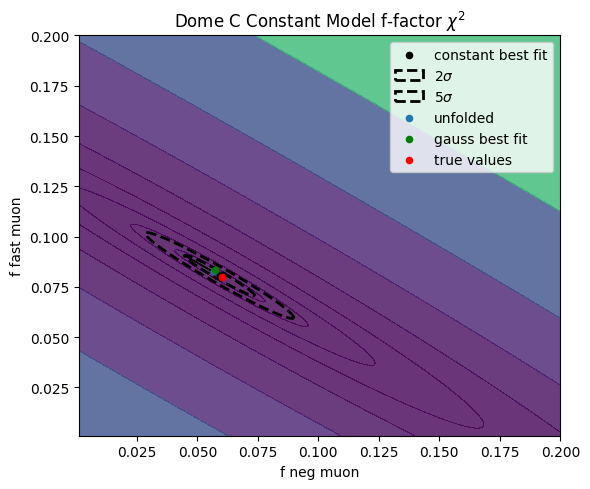

In [34]:
# Same as above, but with f_neg on the x-axis

from matplotlib.patches import Ellipse

C = C0[0].T
Sigma_f_inv = C.T @ Sigma_inv @ C
Sigma_f = np.linalg.inv(Sigma_f_inv)
f_var, f_vec = np.linalg.eig(Sigma_f)

C_exp = CO_exp

f = f_hat_null[0]
f_prime = f + f_vec[:,0]*np.sqrt(f_var[0])*0.

# make eigenvectors point up (looks nice on plot)
f_vec[:,0] *= -1. if f_vec[0,0]<0. else 1.
f_vec[:,1] *= -1. if f_vec[0,1]<0. else 1.

fig, ax = plt.subplots(1,1, figsize=(6,5), tight_layout=True, sharex=True)

chi2_best = (C@f_prime-C_exp).T@Sigma_inv@(C@f_prime-C_exp)
sig1_dist = np.sqrt(stats.chi2.isf(stats.norm.sf(2.)*2., len(C_exp)-len(f)) - chi2_best)

w = 0.02
df = 0.001
#f0_grid = np.arange(f[0]-w, f[0]+w+df, df)
#f1_grid = np.arange(f[1]-w, f[1]+w+df, df)
f0_grid = np.arange(df, 0.2+df, df)
f1_grid = np.arange(df, 0.2+df, df)
f_grid = np.flip(np.array(np.meshgrid(f1_grid, f0_grid)), axis=0).swapaxes(0,1)
chi2_grid = np.sum( (C@f_grid-(C_exp).reshape((1,-1,1))) * (Sigma_inv@(C@f_grid-(C_exp).reshape((1,-1,1)))), axis=1)

# chi2 without errors
#chi2_grid = np.sum( (C@f_grid-(C_exp-C_n[i,0,0]*f_n).reshape((1,-1,1)))**2 /(C@f_grid + (C_n[i,0,0]*f_n).reshape((1,-1,1))), axis=1)

#levels = stats.chi2.isf(stats.norm.sf([0.,0.5,1.,1.5,2.,2.5,3.,4.,5.,6.,8.,10.,20.])*2., len(C_exp)-len(f))
#print(levels)

cf = ax.contourf(f1_grid, f0_grid, chi2_grid, alpha=0.8, levels=np.logspace(np.log10(np.min(chi2_grid)),np.log10(np.max(chi2_grid)),10))

plt.scatter(*np.flip(f), s=20, c='k', label='constant best fit')
plt.arrow(f[1],f[0],f_vec[1,0]*np.sqrt(f_var[0])*sig1_dist,f_vec[0,0]*np.sqrt(f_var[0])*sig1_dist, width=0.01*w, length_includes_head=True, fc='k')
plt.arrow(f[1],f[0],f_vec[1,1]*np.sqrt(f_var[1])*sig1_dist,f_vec[0,1]*np.sqrt(f_var[1])*sig1_dist, width=0.01*w, length_includes_head=True, fc='k')

for sig_r in [2,5]:
    sig_dist = np.sqrt(stats.chi2.isf(stats.norm.sf(sig_r)*2., len(C_exp)-len(f)) - chi2_best)
    ellipse = Ellipse(xy=np.flip(f), width=np.sqrt(f_var[0])*2*sig_dist, height=np.sqrt(f_var[1])*2*sig_dist, angle=np.arccos(f_vec[1,0])*180/np.pi, ec='k', fc='None', lw=2, ls='--', label=r'{}$\sigma$'.format(sig_r))
    ax.add_patch(ellipse)
    
plt.scatter(*np.flip(f_u*u['unfolded'][-1]), s=20, label='unfolded')
plt.scatter(*np.flip((f_unit[i_f]*(f_hat[i_p,i_a,i_c,i_w,i_f]+a[i_a]*f_gauss[i_c,i_w])[-1])), s=20, c='g', label='gauss best fit')
plt.scatter(*np.flip(f_true), s=20, c='r', label='true values')

ax.set(
    xlabel='f neg muon',
    #xlim = (f[0]-0.01,f[0]+0.01),
    ylabel='f fast muon',
    #ylim = (f[1]-0.01,f[1]+0.01)
)
ax.legend()
plt.title(r'Dome C Constant Model f-factor $\chi^2$')
plt.show()

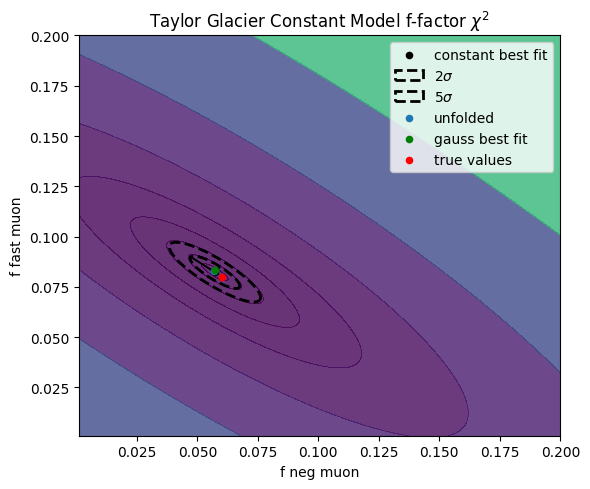

In [35]:
# Same as above, but with f_neg on the x-axis

from matplotlib.patches import Ellipse

C = C0_TG[0,0].T
Sigma_f_inv = C.T @ Sigma_inv_TG @ C
Sigma_f = np.linalg.inv(Sigma_f_inv)
f_var, f_vec = np.linalg.eig(Sigma_f)

C_exp = CO_exp_TG

f = f_hat_null_TG[0,0]
f_prime = f + f_vec[:,0]*np.sqrt(f_var[0])*0.

# make eigenvectors point up (looks nice on plot)
f_vec[:,0] *= -1. if f_vec[0,0]<0. else 1.
f_vec[:,1] *= -1. if f_vec[0,1]<0. else 1.

fig, ax = plt.subplots(1,1, figsize=(6,5), tight_layout=True, sharex=True)

chi2_best = (C@f_prime-C_exp).T@Sigma_inv_TG@(C@f_prime-C_exp)
sig1_dist = np.sqrt(stats.chi2.isf(stats.norm.sf(2.)*2., len(C_exp)-len(f)) - chi2_best)

w = 0.02
df = 0.001
#f0_grid = np.arange(f[0]-w, f[0]+w+df, df)
#f1_grid = np.arange(f[1]-w, f[1]+w+df, df)
f0_grid = np.arange(df, 0.2+df, df)
f1_grid = np.arange(df, 0.2+df, df)
f_grid = np.flip(np.array(np.meshgrid(f1_grid, f0_grid)), axis=0).swapaxes(0,1)
chi2_grid = np.sum( (C@f_grid-(C_exp).reshape((1,-1,1))) * (Sigma_inv_TG@(C@f_grid-(C_exp).reshape((1,-1,1)))), axis=1)

# chi2 without errors
#chi2_grid = np.sum( (C@f_grid-(C_exp-C_n[i,0,0]*f_n).reshape((1,-1,1)))**2 /(C@f_grid + (C_n[i,0,0]*f_n).reshape((1,-1,1))), axis=1)

#levels = stats.chi2.isf(stats.norm.sf([0.,0.5,1.,1.5,2.,2.5,3.,4.,5.,6.,8.,10.,20.])*2., len(C_exp)-len(f))
#print(levels)

cf = ax.contourf(f1_grid, f0_grid, chi2_grid, alpha=0.8, levels=np.logspace(np.log10(np.min(chi2_grid)),np.log10(np.max(chi2_grid)),10))

plt.scatter(*np.flip(f), s=20, c='k', label='constant best fit')
plt.arrow(f[1],f[0],f_vec[1,0]*np.sqrt(f_var[0])*sig1_dist,f_vec[0,0]*np.sqrt(f_var[0])*sig1_dist, width=0.01*w, length_includes_head=True, fc='k')
plt.arrow(f[1],f[0],f_vec[1,1]*np.sqrt(f_var[1])*sig1_dist,f_vec[0,1]*np.sqrt(f_var[1])*sig1_dist, width=0.01*w, length_includes_head=True, fc='k')

for sig_r in [2,5]:
    sig_dist = np.sqrt(stats.chi2.isf(stats.norm.sf(sig_r)*2., len(C_exp)-len(f)) - chi2_best)
    ellipse = Ellipse(xy=np.flip(f), width=np.sqrt(f_var[0])*2*sig_dist, height=np.sqrt(f_var[1])*2*sig_dist, angle=np.arccos(f_vec[1,0])*180/np.pi, ec='k', fc='None', lw=2, ls='--', label=r'{}$\sigma$'.format(sig_r))
    ax.add_patch(ellipse)
    
plt.scatter(*np.flip(f_u*u['unfolded'][-1]), s=20, label='unfolded')
plt.scatter(*np.flip((f_unit[i_f]*(f_hat[i_p,i_a,i_c,i_w,i_f]+a[i_a]*f_gauss[i_c,i_w])[-1])), s=20, c='g', label='gauss best fit')
plt.scatter(*np.flip(f_true), s=20, c='r', label='true values')

ax.set(
    xlabel='f neg muon',
    #xlim = (f[0]-0.01,f[0]+0.01),
    ylabel='f fast muon',
    #ylim = (f[1]-0.01,f[1]+0.01)
)
ax.legend()
plt.title(r'Taylor Glacier Constant Model f-factor $\chi^2$')
plt.show()